# 🗳️ Previsão de Criticidade de Urnas Eleitorais — MLP
## Eleições 2022 · Sergipe (TRE-SE)

Este notebook reconstrói o dataset completo com os quatro níveis de criticidade:

| Nível | Descrição | Critério |
|-------|-----------|----------|
| **0** | Normal (sem atraso) | ATRASO_FILA_MINUTOS == 0 |
| **1** | Atenção | ATRASO < 32.15 min |
| **2** | Crítico | 32.15 ≤ ATRASO < 89.36 min |
| **3** | Muito Crítico | ATRASO ≥ 89.36 min |

**Fluxo:**
1. Carrega os CSVs de nível 1, 2 e 3 já processados
2. Reconstrói as urnas de **nível 0** a partir do `df_csv` (log parseado) + perfil eleitoral
3. Unifica os quatro níveis em um único dataset
4. Treina uma **MLP** para classificação multiclasse


In [1]:
# ─── Imports ────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ─── Constantes do modelo de criticidade ─────────────────────────────────────
MEDIA_1T  = 32.15   # minutos — fronteira nível 1 / nível 2
CORTE_1T  = 89.36   # minutos — fronteira nível 2 / nível 3

# ─── Chaves de identificação de urna ─────────────────────────────────────────
CHAVES_URNA = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO']

# ─── Colunas da máquina (features brutas) ────────────────────────────────────
COLUNAS_MAQUINA = [
    'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA',
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17',
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE',
    'SEM_BIOMETRIA', 'TITULO_INVALIDO', 'ATRASO_FILA_MINUTOS', 'STATUS'
]

print("✅ Imports carregados com sucesso.")


✅ Imports carregados com sucesso.


## 1. Carregamento dos Datasets de Nível 1, 2 e 3

In [2]:
# Ajuste os caminhos conforme a localização dos arquivos na sua máquina
PATH_N1 = 'urnas_perfil_nivel1.csv'
PATH_N2 = 'urnas_perfil_nivel2.csv'
PATH_N3 = 'urnas_perfil_nivel3.csv'

n1 = pd.read_csv(PATH_N1, sep=';', encoding='utf-8-sig')
n2 = pd.read_csv(PATH_N2, sep=';', encoding='utf-8-sig')
n3 = pd.read_csv(PATH_N3, sep=';', encoding='utf-8-sig')

n1['STATUS'] = 1
n2['STATUS'] = 2
n3['STATUS'] = 3

print(f"Nível 1 — {len(n1):>5} urnas | {n1.shape[1]} colunas")
print(f"Nível 2 — {len(n2):>5} urnas | {n2.shape[1]} colunas")
print(f"Nível 3 — {len(n3):>5} urnas | {n3.shape[1]} colunas")


Nível 1 —  1040 urnas | 54 colunas
Nível 2 —   490 urnas | 54 colunas
Nível 3 —   133 urnas | 53 colunas


## 2. Reconstrução das Urnas de Nível 0

As urnas de nível 0 são aquelas do **1º Turno**, sem contingência, com **ATRASO_FILA_MINUTOS == 0**.
Elas não foram incluídas nos CSVs originais pois o notebook analisava apenas urnas atrasadas.

**Fontes necessárias** (mesmas usadas para gerar os níveis 1-3):
- `df_csv.csv` — saída do parsing dos arquivos de log (gerado pela célula 0 do notebook original) **ou** a pasta `data/processed/` com os `.logd.dat`
- `perfil_eleitor_secao_2022_SE.csv` — perfil eleitoral por seção (TSE)


In [6]:
# ─── Configuração de caminhos ────────────────────────────────────────────────
# Opção A: usar o df_csv.csv já gerado (mais rápido)
PATH_DF_CSV   = 'df_csv.csv'
# Opção B: reprocessar os logs (necessário se df_csv.csv não existir)
PATH_LOGS     = 'data/processed/'
PATH_MUN_MAP  = 'municipio_tse_ibge.csv'
# Perfil eleitoral (obrigatório para enriquecimento com ESC_/IDADE_/GENERO_)
PATH_PERFIL   = 'perfil_eleitor_secao_2022_SE.csv'

REBUILD_FROM_LOGS = False   # mude para True se não tiver df_csv.csv

# ─── Funções auxiliares ───────────────────────────────────────────────────────
def _parse_logs(path_logs, path_mun_map):
    """Replica a lógica da célula 0 do notebook original."""
    import os
    from datetime import datetime
    nomes_mun = pd.read_csv(path_mun_map, sep=';', encoding='latin1')
    dados = []
    for raiz, _, arquivos in os.walk(path_logs):
        for nome in arquivos:
            if not nome.endswith('logd.dat'):
                continue
            caminho = os.path.join(raiz, nome)
            municipio = zona = secao = None
            urna_contingencia = "Não"
            timeout_biometria = tecla_indevida = inatividade = sem_biometria = titulo_invalido = 0
            inicio_voto = None
            tdvpe_por_turno = {
                "1º Turno": {"antes_17": [], "depois_17": []},
                "2º Turno": {"antes_17": [], "depois_17": []},
            }
            huv_por_turno = {"1º Turno": None, "2º Turno": None}
            turno_atual = "1º Turno"

            with open(caminho, 'r', encoding='latin1', errors='replace') as f:
                for linha in f:
                    tb = linha.lower()
                    if "urna de contingência" in tb:
                        urna_contingencia = "Sim"
                    if "iniciando aplicação" in tb and "turno" in tb:
                        turno_atual = "1º Turno" if "1º turno" in tb else "2º Turno"
                    if "município" in tb and municipio is None:
                        municipio = tb.split("município")[1].replace(":", "").split()[0]
                    elif "zona eleitoral" in tb and zona is None:
                        zona = tb.split("zona eleitoral")[1].replace(":", "").split()[0]
                    elif "seção eleitoral" in tb:
                        s = tb.split("seção eleitoral")[1].replace(":", "").split()[0]
                        if secao is None or secao in ('0', '00', '000', '0000'):
                            secao = s
                    elif "eleitor foi habilitado" in tb:
                        inicio_voto = datetime.strptime(linha[:19], "%d/%m/%Y %H:%M:%S")
                    elif "o voto do eleitor foi computado" in tb and inicio_voto:
                        fim = datetime.strptime(linha[:19], "%d/%m/%Y %H:%M:%S")
                        voto = (fim - inicio_voto).total_seconds()
                        bucket = "antes_17" if fim.hour < 17 else "depois_17"
                        tdvpe_por_turno[turno_atual][bucket].append(voto)
                        huv_por_turno[turno_atual] = fim.strftime("%H:%M:%S")
                        inicio_voto = None
                    if "timeout de reconhecimento do dedo" in tb and turno_atual == "1º Turno":
                        timeout_biometria += 1
                    if "o eleitor não possui biometria" in tb and turno_atual == "1º Turno":
                        sem_biometria += 1
                    if "tecla indevida pressionada" in tb and turno_atual == "1º Turno":
                        tecla_indevida += 1
                    if "eleitor sem atividade por " in tb and turno_atual == "1º Turno":
                        inatividade += 1
                    if "título inválido" in tb and turno_atual == "1º Turno":
                        titulo_invalido += 1

            for turno, cestas in tdvpe_por_turno.items():
                va, vd = cestas["antes_17"], cestas["depois_17"]
                if va or vd:
                    dados.append({
                        'NM_MUNICIPIO': municipio, 'NR_ZONA': zona, 'NR_SECAO': secao,
                        'TURNO': turno, 'CONTINGENCIA': urna_contingencia,
                        'QT_ELEITORES_ANTES_17': len(va),
                        'DELTA_T_ANTES_17': round(np.mean(va), 2) if va else 0.0,
                        'DESVIO_ANTES_17': round(np.std(va), 2) if len(va) > 1 else 0.0,
                        'QT_ELEITORES_DEPOIS_17': len(vd),
                        'DELTA_T_DEPOIS_17': round(np.mean(vd), 2) if vd else 0.0,
                        'DESVIO_DEPOIS_17': round(np.std(vd), 2) if len(vd) > 1 else 0.0,
                        'ULTIMO_VOTO': huv_por_turno[turno],
                        'TIMEOUT_BIOMETRIA': timeout_biometria,
                        'TECLA_INDEVIDA': tecla_indevida,
                        'INATIVIDADE': inatividade,
                        'SEM_BIOMETRIA': sem_biometria,
                        'TITULO_INVALIDO': titulo_invalido,
                    })
    df = pd.DataFrame(dados)
    # Mapear código municipal → nome
    mun_se = nomes_mun[nomes_mun['SG_UF'] == 'SE'].copy()
    mun_se['CD_MUNICIPIO_TSE'] = mun_se['CD_MUNICIPIO_TSE'].astype(str)
    df['NM_MUNICIPIO'] = df['NM_MUNICIPIO'].astype(str)
    df = df.merge(mun_se[['CD_MUNICIPIO_TSE', 'NM_MUNICIPIO_TSE']],
                  left_on='NM_MUNICIPIO', right_on='CD_MUNICIPIO_TSE', how='left')
    df = df.drop(columns=['NM_MUNICIPIO', 'CD_MUNICIPIO_TSE'], errors='ignore')
    df = df.rename(columns={'NM_MUNICIPIO_TSE': 'NM_MUNICIPIO'})
    return df


def _enriquecer_com_perfil(df_urnas, df_perfil):
    """Faz o merge e o pivot da mesma forma que as células 22-24 do notebook original."""
    # Garantir tipos compatíveis
    for col in ['NR_ZONA', 'NR_SECAO']:
        df_urnas[col] = pd.to_numeric(df_urnas[col], errors='coerce').astype('Int64')
        df_perfil[col] = pd.to_numeric(df_perfil[col], errors='coerce').astype('Int64')
    df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].astype(str).str.upper().str.strip()
    df_urnas['NM_MUNICIPIO'] = df_urnas['NM_MUNICIPIO'].astype(str).str.upper().str.strip()

    df_merged = df_urnas.merge(df_perfil,
                               on=['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
                               how='inner')

    chaves = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO']
    cols_maq = [c for c in df_urnas.columns]

    df_base = df_merged[cols_maq].drop_duplicates(subset=chaves)

    def _pivot(coluna_agrup, prefix):
        piv = df_merged.pivot_table(
            index=chaves, columns=coluna_agrup,
            values='QT_ELEITORES_PERFIL', aggfunc='sum', fill_value=0
        ).reset_index()
        piv.columns = chaves + [f'{prefix}{c}' for c in piv.columns[len(chaves):]]
        return piv

    df_esc    = _pivot('DS_GRAU_ESCOLARIDADE', 'ESC_')
    df_idade  = _pivot('DS_FAIXA_ETARIA',      'IDADE_')
    df_genero = _pivot('DS_GENERO',             'GENERO_')

    df_pcd = (df_merged.groupby(chaves)['QT_ELEITORES_DEFICIENCIA']
              .sum().reset_index()
              .rename(columns={'QT_ELEITORES_DEFICIENCIA': 'QTD_PCD'}))
    df_bio = (df_merged.groupby(chaves)['QT_ELEITORES_BIOMETRIA']
              .sum().reset_index()
              .rename(columns={'QT_ELEITORES_BIOMETRIA': 'QTD_PERFIL_BIOMETRIA'}))

    df_final = df_base.copy()
    for df_aux in [df_esc, df_idade, df_genero, df_pcd, df_bio]:
        df_final = pd.merge(df_final, df_aux, on=chaves, how='left')

    cols_novas = [c for c in df_final.columns if c not in cols_maq]
    df_final[cols_novas] = df_final[cols_novas].fillna(0).astype(int)
    return df_final

# ─────────────────────────────────────────────────────────────────────────────
# PASSO 1: carregar ou reprocessar df_csv
# ─────────────────────────────────────────────────────────────────────────────
if REBUILD_FROM_LOGS:
    print("Reprocessando logs (pode demorar alguns minutos)...")
    df_csv = _parse_logs(PATH_LOGS, PATH_MUN_MAP)
    df_csv.to_csv('df_csv.csv', index=False, sep=';', encoding='utf-8-sig')
    print(f"   → {len(df_csv)} registros salvos em df_csv.csv")
else:
    df_csv = pd.read_csv(PATH_DF_CSV, sep=';', encoding='utf-8-sig')
    print(f"df_csv carregado: {len(df_csv)} registros")

# PASSO 2: calcular ATRASO_FILA_MINUTOS
df_csv['TEMP_HORA'] = pd.to_datetime(df_csv['ULTIMO_VOTO'], format='%H:%M:%S', errors='coerce')
minutos = df_csv['TEMP_HORA'].dt.hour * 60 + df_csv['TEMP_HORA'].dt.minute
df_csv['ATRASO_FILA_MINUTOS'] = (minutos - 17 * 60).clip(lower=0)
df_csv = df_csv.drop(columns=['TEMP_HORA'])

# PASSO 3: filtrar urnas de nível 0 (1º turno, sem contingência, sem atraso)
mask_n0 = (
    (df_csv['TURNO'] == '1º Turno') &
    (df_csv['CONTINGENCIA'] == 'Não') &
    (df_csv['ATRASO_FILA_MINUTOS'] == 0)
)
df_nivel0_bruto = df_csv[mask_n0].copy()
df_nivel0_bruto['STATUS'] = 0
print(f"\n📊 Urnas de nível 0 (sem atraso): {len(df_nivel0_bruto)}")

# PASSO 4: enriquecer com perfil eleitoral
print("\nCarregando perfil eleitoral...")
df_perfil = pd.read_csv(PATH_PERFIL, sep=';', encoding='latin1')
print(f"   → {len(df_perfil)} registros de perfil carregados")

n0 = _enriquecer_com_perfil(df_nivel0_bruto, df_perfil)
n0['STATUS'] = 0
print(f"\nNível 0 após enriquecimento: {len(n0)} urnas | {n0.shape[1]} colunas")


df_csv carregado: 10732 registros

📊 Urnas de nível 0 (sem atraso): 3367

Carregando perfil eleitoral...
   → 780178 registros de perfil carregados

Nível 0 após enriquecimento: 0 urnas | 22 colunas


## 3. Unificação dos Quatro Níveis

In [3]:
# ─── Harmonizar colunas entre os 4 datasets ───────────────────────────────────
# N3 não possui IDADE_Inválido — adicionamos zerada para uniformidade
all_dfs = [n1, n2, n3]
all_cols = set()
for d in all_dfs:
    all_cols.update(d.columns)

def _add_missing_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df[c] = 0
    return df[sorted(all_cols)]

all_dfs = [_add_missing_cols(df.copy(), all_cols) for df in all_dfs]
n1, n2, n3 = all_dfs

dataset = pd.concat(all_dfs, ignore_index=True)
dataset['STATUS'] = dataset['STATUS'].astype(int)

print(f"Dataset unificado: {dataset.shape[0]} urnas × {dataset.shape[1]} colunas")
print()
print("Distribuição por nível:")
contagem = dataset['STATUS'].value_counts().sort_index()
for nivel, cnt in contagem.items():
    pct = cnt / len(dataset) * 100
    barra = '█' * int(pct / 2)
    print(f"  Nível {nivel}: {cnt:>5} urnas ({pct:5.1f}%)  {barra}")

Dataset unificado: 1663 urnas × 54 colunas

Distribuição por nível:
  Nível 1:  1040 urnas ( 62.5%)  ███████████████████████████████
  Nível 2:   490 urnas ( 29.5%)  ██████████████
  Nível 3:   133 urnas (  8.0%)  ███


## 4. Análise Exploratória

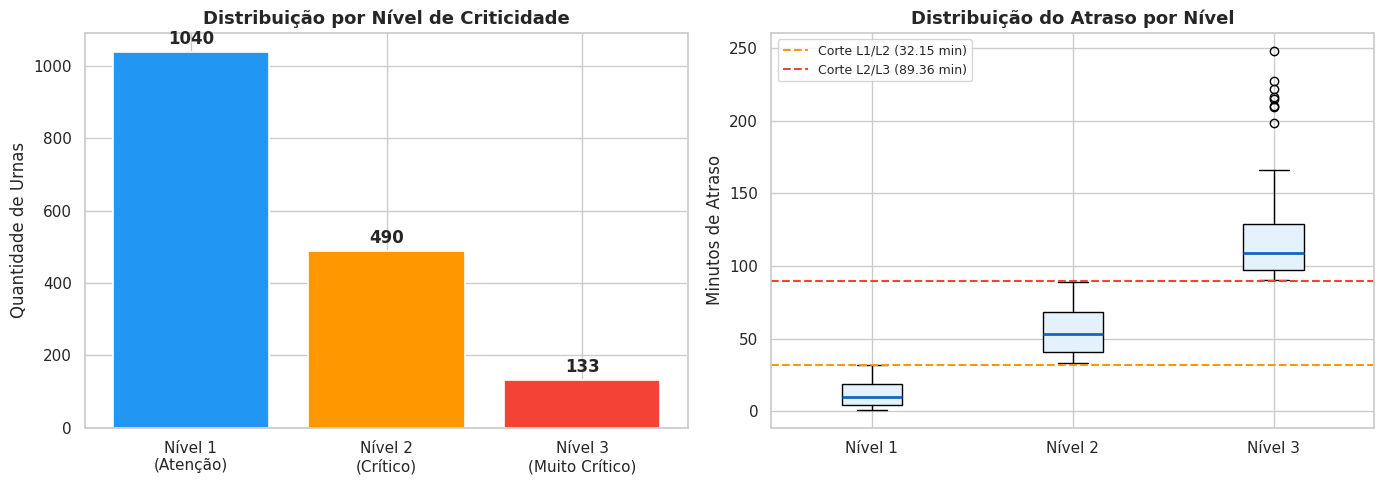

✅ Figura salva em eda_distribuicao.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Distribuição de classes
cores = ['#2196F3', '#FF9800', '#F44336']
rotulos = ['Nível 1\n(Atenção)', 'Nível 2\n(Crítico)', 'Nível 3\n(Muito Crítico)']
vals = [dataset[dataset.STATUS == i].shape[0] for i in range(1, 4)]

bars = axes[0].bar(rotulos, vals, color=cores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribuição por Nível de Criticidade', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Urnas')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{v}', ha='center', va='bottom', fontweight='bold')

# — Boxplot do atraso por nível
dataset_atrasados = dataset[dataset['STATUS'] > 0].copy()
bp = axes[1].boxplot(
    [dataset_atrasados[dataset_atrasados.STATUS == i]['ATRASO_FILA_MINUTOS'].dropna()
     for i in [1, 2, 3]],
    labels=['Nível 1', 'Nível 2', 'Nível 3'],
    patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_title('Distribuição do Atraso por Nível', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Minutos de Atraso')
axes[1].axhline(MEDIA_1T, color='#FF9800', linestyle='--', label=f'Corte L1/L2 ({MEDIA_1T} min)')
axes[1].axhline(CORTE_1T, color='#F44336', linestyle='--', label=f'Corte L2/L3 ({CORTE_1T} min)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura salva em eda_distribuicao.png")


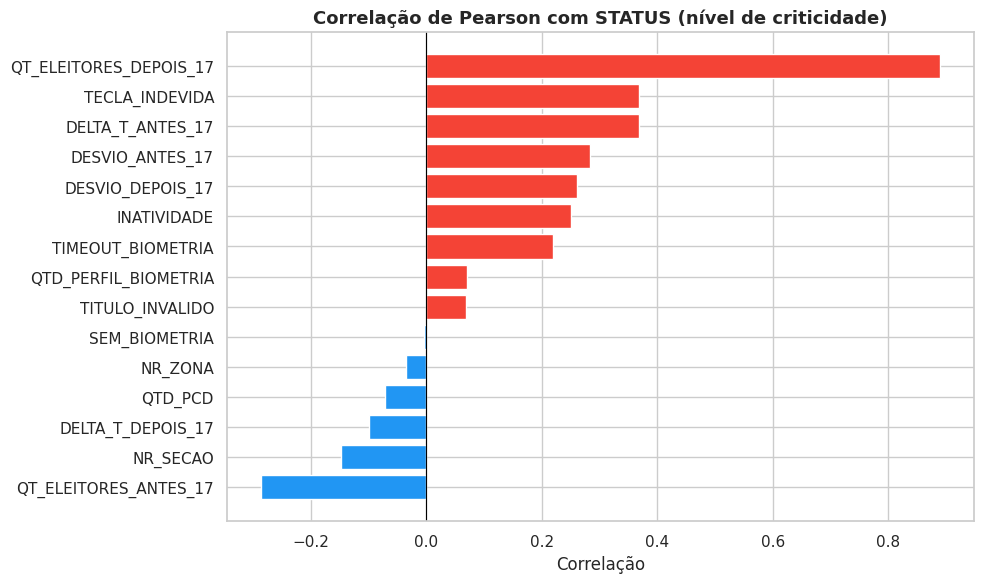

In [26]:
# ─── Correlação das features numéricas com o STATUS ───────────────────────────
features_interesse = [
    'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE',
    'SEM_BIOMETRIA', 'TITULO_INVALIDO',
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17',
    'QTD_PCD', 'QTD_PERFIL_BIOMETRIA',
]
feats_disponiveis = [f for f in features_interesse if f in dataset.columns]

corr = dataset[feats_disponiveis + ['STATUS']].corr()['STATUS'].drop('STATUS').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
cores_corr = ['#F44336' if v > 0 else '#2196F3' for v in corr.values]
ax.barh(corr.index, corr.values, color=cores_corr, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlação de Pearson com STATUS (nível de criticidade)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação')
plt.tight_layout()
plt.savefig('eda_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Pré-Processamento para a MLP

In [32]:
# ─── Colunas a excluir (identificadores, texto, alvo) ─────────────────────────
EXCLUIR = ['NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO',
           'CONTINGENCIA', 'ULTIMO_VOTO', 'STATUS', 'ATRASO_FILA_MINUTOS',
           'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
           'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17'
          ]

# Features numéricas disponíveis
feature_cols = [c for c in dataset.columns if c not in EXCLUIR]

# Converter tudo para numérico (colunas de idade/escolaridade já são int)
X_raw = dataset[feature_cols].copy()
for col in X_raw.columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

# Tratar valores ausentes (preencher com 0 — feature de contagem)
X_raw = X_raw.fillna(0)

y = dataset['STATUS'].astype(int)

print(f"Features de entrada : {X_raw.shape[1]}")
print(f"Amostras            : {X_raw.shape[0]}")
print(f"Distribuição do alvo:\n{y.value_counts().sort_index()}")


Features de entrada : 41
Amostras            : 1663
Distribuição do alvo:
STATUS
1    1040
2     490
3     133
Name: count, dtype: int64


In [34]:
# ─── Divisão treino / teste estratificada ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino : {X_train.shape[0]} amostras")
print(f"Teste  : {X_test.shape[0]} amostras")
print()
print("Distribuição no treino:")
for nivel, cnt in y_train.value_counts().sort_index().items():
    print(f"  Nível {nivel}: {cnt}")
print("\nDistribuição no teste:")
for nivel, cnt in y_test.value_counts().sort_index().items():
    print(f"  Nível {nivel}: {cnt}")


Treino : 1330 amostras
Teste  : 333 amostras

Distribuição no treino:
  Nível 1: 832
  Nível 2: 392
  Nível 3: 106

Distribuição no teste:
  Nível 1: 208
  Nível 2: 98
  Nível 3: 27


## 6. Treinamento da MLP

In [35]:
# ─── Pipeline: StandardScaler → MLP ──────────────────────────────────────────
# Arquitetura: 2 camadas ocultas com regularização L2
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # duas camadas ocultas
    activation='relu',
    solver='adam',
    alpha=1e-3,                    # regularização L2
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp)
])

print("🏋️ Treinando MLP...")
pipeline.fit(X_train, y_train)
print(f"✅ Treinamento concluído em {mlp.n_iter_} épocas.")


🏋️ Treinando MLP...
✅ Treinamento concluído em 31 épocas.


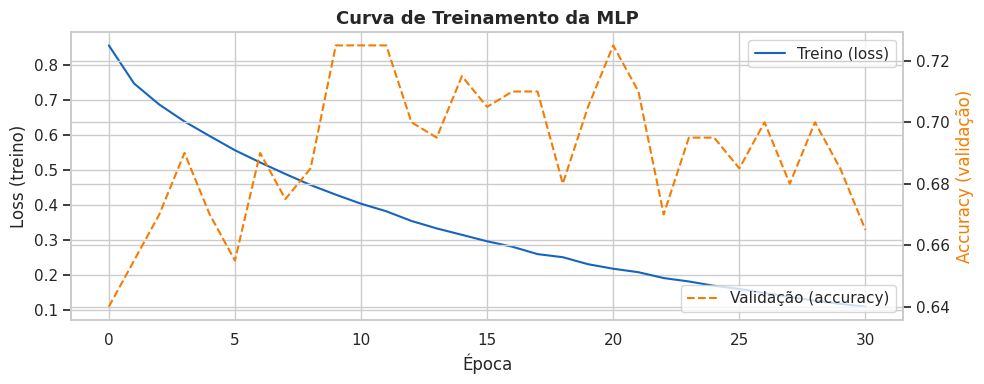

In [36]:
# ─── Curva de Loss (treinamento vs validação) ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp.loss_curve_, label='Treino (loss)', color='#1565C0')
if mlp.validation_scores_ is not None:
    ax_r = ax.twinx()
    ax_r.plot(mlp.validation_scores_, label='Validação (accuracy)',
              color='#F57C00', linestyle='--')
    ax_r.set_ylabel('Accuracy (validação)', color='#F57C00')
    ax_r.legend(loc='lower right')
ax.set_title('Curva de Treinamento da MLP', fontsize=13, fontweight='bold')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (treino)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('mlp_curva_treino.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Avaliação no Conjunto de Teste

In [31]:
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia geral: {acc:.4f} ({acc*100:.2f}%)\n")
print("=" * 58)
print(classification_report(y_test, y_pred,
      target_names=['Nível 1', 'Nível 2', 'Nível 3']))


Acurácia geral: 0.6877 (68.77%)

              precision    recall  f1-score   support

     Nível 1       0.79      0.83      0.81       208
     Nível 2       0.48      0.52      0.50        98
     Nível 3       0.56      0.19      0.28        27

    accuracy                           0.69       333
   macro avg       0.61      0.51      0.53       333
weighted avg       0.68      0.69      0.68       333



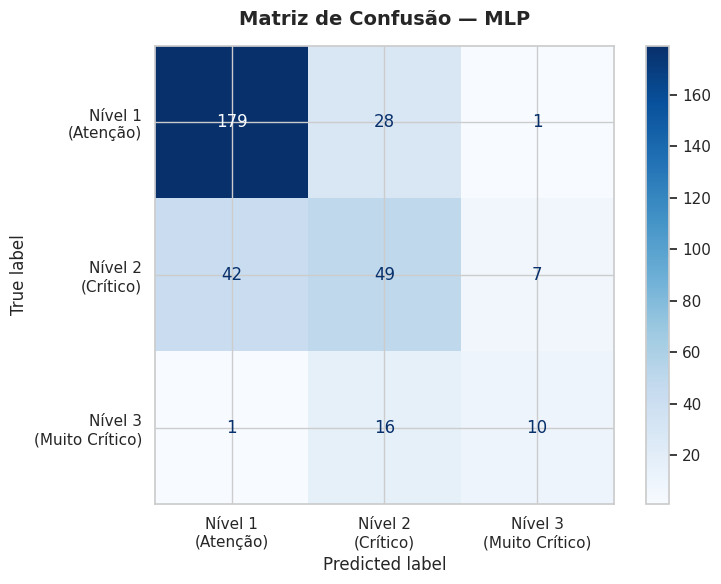

In [21]:
# ─── Matriz de Confusão ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
rotulos_classes = ['Nível 1\n(Atenção)',
                   'Nível 2\n(Crítico)', 'Nível 3\n(Muito Crítico)']

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rotulos_classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusão — MLP', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('mlp_confusao.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Validação Cruzada Estratificada (k=5)

🔁 Executando validação cruzada (5-fold)... pode levar alguns minutos.

Acurácia por fold: ['0.7417', '0.7357', '0.7057', '0.7139', '0.6717']
Média  : 0.7137
Desvio : 0.0249
IC 95% : [0.6639 , 0.7636]


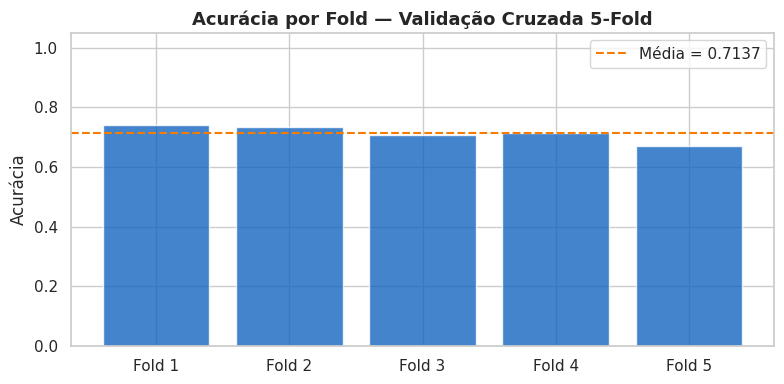

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Criar novo pipeline para não contaminar o modelo treinado
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        alpha=1e-3, batch_size=64, learning_rate='adaptive',
        learning_rate_init=1e-3, max_iter=500,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=20, random_state=42, verbose=False,
    ))
])

print("🔁 Executando validação cruzada (5-fold)... pode levar alguns minutos.")
scores_cv = cross_val_score(pipeline_cv, X_raw, y, cv=skf,
                            scoring='accuracy', n_jobs=-1)

print(f"\nAcurácia por fold: {[f'{s:.4f}' for s in scores_cv]}")
print(f"Média  : {scores_cv.mean():.4f}")
print(f"Desvio : {scores_cv.std():.4f}")
print(f"IC 95% : [{scores_cv.mean() - 2*scores_cv.std():.4f} , "
      f"{scores_cv.mean() + 2*scores_cv.std():.4f}]")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), scores_cv, color='#1565C0', alpha=0.8, edgecolor='white')
ax.axhline(scores_cv.mean(), color='#F57C00', linestyle='--',
           label=f'Média = {scores_cv.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('Acurácia')
ax.set_ylim(0, 1.05)
ax.set_title('Acurácia por Fold — Validação Cruzada 5-Fold', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('mlp_cv.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Importância Aproximada das Features (Permutation)

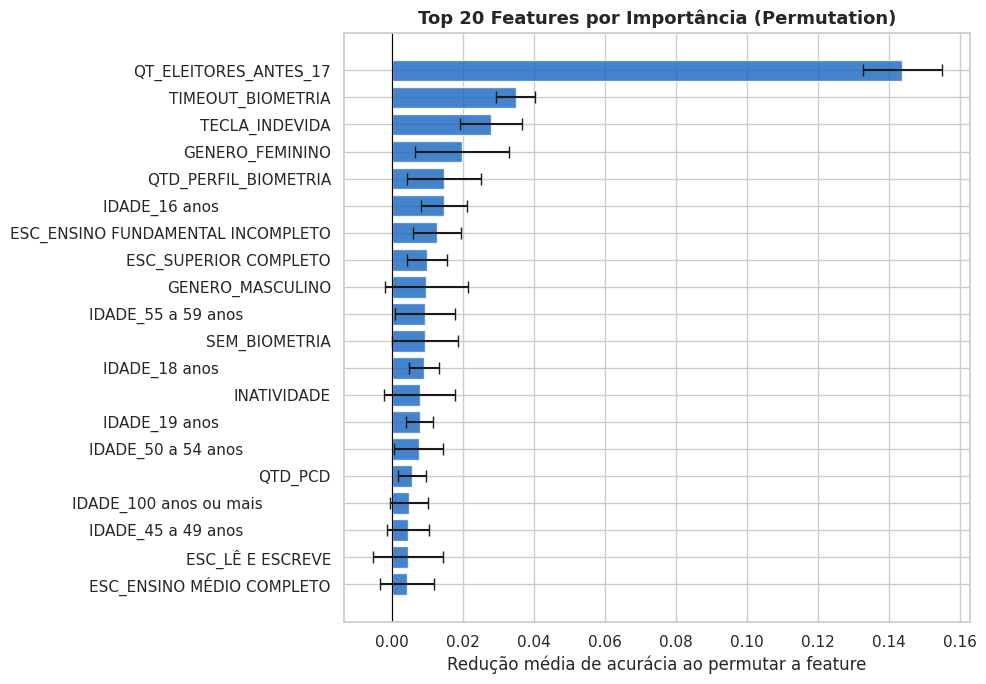

In [23]:
from sklearn.inspection import permutation_importance

# Usar subconjunto para performance
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
result = permutation_importance(
    pipeline.named_steps['mlp'], X_test_scaled, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

imp_mean = pd.Series(result.importances_mean, index=feature_cols)
imp_std  = pd.Series(result.importances_std,  index=feature_cols)

# Top 20 mais importantes
top20 = imp_mean.sort_values(ascending=False).head(20)
top20_std = imp_std[top20.index]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(top20))
ax.barh(list(top20.index)[::-1], list(top20.values)[::-1],
        xerr=list(top20_std.values)[::-1],
        color='#1565C0', alpha=0.8, edgecolor='white', capsize=4)
ax.set_title('Top 20 Features por Importância (Permutation)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Redução média de acurácia ao permutar a feature')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('mlp_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Resumo Final

In [24]:
print("=" * 60)
print("          RESUMO DO EXPERIMENTO")
print("=" * 60)
print()
print(f"  Dataset total          : {len(dataset)} urnas")
print(f"  Features               : {X_raw.shape[1]}")
print()
print("  Distribuição:")
for i, lbl in enumerate(['Nível 0 (Normal)', 'Nível 1 (Atenção)',
                          'Nível 2 (Crítico)', 'Nível 3 (Muito Crítico)']):
    n = (y == i).sum()
    print(f"    {lbl:<28}: {n:>5} ({n/len(y)*100:.1f}%)")
print()
print(f"  Acurácia (test set)    : {acc*100:.2f}%")
print(f"  Acurácia (CV 5-fold)   : {scores_cv.mean()*100:.2f}% ± {scores_cv.std()*100:.2f}%")
print()
print("  Arquitetura MLP:")
print(f"    Camadas ocultas      : {mlp.hidden_layer_sizes}")
print(f"    Ativação             : {mlp.activation}")
print(f"    Otimizador           : {mlp.solver}")
print(f"    Regularização L2 (α) : {mlp.alpha}")
print(f"    Épocas treinadas     : {mlp.n_iter_}")
print()
print("  Arquivos gerados:")
print("    dataset_urnas_todos_niveis.csv")
print("    eda_distribuicao.png")
print("    eda_correlacao.png")
print("    mlp_curva_treino.png")
print("    mlp_confusao.png")
print("    mlp_cv.png")
print("    mlp_importancia_features.png")
print("=" * 60)


          RESUMO DO EXPERIMENTO

  Dataset total          : 1663 urnas
  Features               : 42

  Distribuição:
    Nível 0 (Normal)            :     0 (0.0%)
    Nível 1 (Atenção)           :  1040 (62.5%)
    Nível 2 (Crítico)           :   490 (29.5%)
    Nível 3 (Muito Crítico)     :   133 (8.0%)

  Acurácia (test set)    : 71.47%
  Acurácia (CV 5-fold)   : 71.37% ± 2.49%

  Arquitetura MLP:
    Camadas ocultas      : (128, 64)
    Ativação             : relu
    Otimizador           : adam
    Regularização L2 (α) : 0.001
    Épocas treinadas     : 31

  Arquivos gerados:
    dataset_urnas_todos_niveis.csv
    eda_distribuicao.png
    eda_correlacao.png
    mlp_curva_treino.png
    mlp_confusao.png
    mlp_cv.png
    mlp_importancia_features.png
